In [ ]:
%load_ext autoreload
%autoreload 2

import os, sys, re
import numpy as np
import pandas as pd
import scanpy as sc
import torch
import time
import PINN
from PINN import reader, models, pl, tl
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from torchdiffeq import odeint

import matplotlib as mpl
import seaborn as sns
from matplotlib.patches import Patch


os.chdir("/home/wz369/rds/hpc-work/PINN_dynamics")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [5]:
import palantir
# import cellrank as cr
import scvelo as scv

In [112]:
sc.settings.set_figure_params(frameon=False, dpi=50, figsize=(3,3))

# Exp configs

In [7]:
# find all config files
config_dir = "logs/ery_mk_Aug1_multiscaled/pde_params_tsense/"
configs = [file for file in os.listdir(config_dir) if file.endswith('.json')]

In [ ]:
# load config for different runs
config_dict = {}
for js in configs:
    version = js.split("_")[0][1:] # after V
    config = PINN.ExperimentConfig(os.path.join(config_dir, js))
    config.experiment_config['checkpoint_dir'] = config.experiment_config['checkpoint_dir'].replace("/ssd/users/Wergillius/Project/PINN_dynamics", "/home/wz369/rds/hpc-work/PINN_dynamics")
    config_dict[version] = config

In [13]:
for v,config in config_dict.items():
    print(v)
    print(config.find_lastest_ckpt())
    print("/n")

0
/home/wz369/rds/hpc-work/PINN_dynamics/logs/ery_mk_Aug1_multiscaled/pde_params_tsense/lightning_logs/version_0/checkpoints/epoch=299-val_loss=0.65300298.ckpt
/n
1
/home/wz369/rds/hpc-work/PINN_dynamics/logs/ery_mk_Aug1_multiscaled/pde_params_tsense/lightning_logs/version_1/checkpoints/epoch=211-val_loss=0.92638135.ckpt
/n


# load data

In [14]:
# # load dataset
dataset_name = config.experiment_config['dataset']
print(dataset_name)
adata = sc.read_h5ad(f'data/{dataset_name}.h5ad')

ery_mk_Aug1


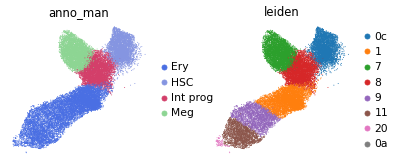

In [59]:
sc.pl.umap(adata, color=['anno_man','leiden'])

# load density transport results

In [ ]:
class DT_analysis:
    r"""
    class to analyze the density transport result from saved files
    """
    def __init__(self, adata, result_dir):
        self.adata = adata
        self.result_dir = result_dir
        self.load_result(result_dir)

    def load_result(self, result_dir):
        r"""
        load the result from saved files, this method returns 4 dictionary with timepoint as key
        
        Saved Properties:
        - cb_dict: a dictionary of cell barcode at its corresponding time point
        - TM_dict: a dictionary of *raw* transport map at its corresponding time point
        - TM_norm_dict: a dictionary of *normalized* transport map at its corresponding time point
        - trajectory_dict: a dictionary of trajectory at its corresponding time point
        """
        # load cell barcode dict
        self.cb_dict = np.load(os.path.join(self.result_dir, 'HSC_cellbarcode.npy'), allow_pickle=True)
        

        # load density intermediate files
        self.TM_dict = {}                        # shape : [cell, step, step]
        self.TM_norm_dict = {}                   # shape : [cell, step, step]
        self.trajectory_dict = {}                # shape : [step+1, cell, n_dim ]


        # load trajectory and transport map
        npy_save_dir = os.path.join(self.result_dir, 'Density_transport')
        for files in os.listdir(npy_save_dir):

            day = files.split('_')[1].replace('Day', '')

            if files.endswith('_Norm_TransportMap.npy'):
                self.TM_norm_dict[day] = np.load(os.path.join(npy_save_dir, files))
            
            elif files.endswith('_TransportMap.npy'):
                self.TM_dict[day] = np.load(os.path.join(npy_save_dir, files))

            elif files.endswith('sim_trajectory.npy'):
                self.trajectory_dict[day] = np.load(os.path.join(npy_save_dir, files))
            
            else:
                print(f'{files} is not a valid file')

    def summarize_cell_proportions(self, df, celltype_list):
        """
        Summarizes the proportion of cell types mapped from neighbors for each cell

        Inputs:
        df : Input DataFrame where each column represents a cell and each row a sample.
        celltype_list : List of cell types to include in the output as columns.
        """
        # Compute normalized value counts for each cell
        proportions = df.apply(lambda col: col.value_counts(normalize=True))
        proportions = proportions.fillna(0).T # cell as index

        # Reindex columns to match the given celltype_list, filling missing with 0
        proportions = proportions.reindex(columns=celltype_list, fill_value=0)

        return proportions
    
    def annotate_trajectory(self, cellstate_key, obs_key, copy=False):
        r"""
        Use the nearest celltype to annotate each step along the simulated trajectory

        Inputs:
        cellstate_key: which cellstate space for the simulation to map to
        obs_key: the key to store the annotation in adata

        Returns:
        celltype_trajectory: with the annotation added
        """
        try:
            # the order matched with that in adata
            celltype_list = self.adata.obs[obs_key].cat.categories
        except:
            celltype_list = self.adata.obs[obs_key].unique()
        

        celltype_trajectory = {}

        for t, traj in self.trajectory_dict.items():

            # cb = self.cb_dict[t]
            
            ct_df = []
            for step in range(1, traj.shape[0]):

                annotations = PINN.tl.assign_nearest_cell(traj[step], self.adata, cellstate_key=cellstate_key, annotation=obs_key)
                proportions = self.summarize_cell_proportions(annotations, celltype_list)

                # assert proportions.shape[0] == len(cb)
                # proportions.index = cb

                proportions['Day'] = t
                proportions['step'] = step
                proportions['cell_index'] = proportions.index
                ct_df.append(proportions)
            
            celltype_trajectory[t] = pd.concat(ct_df).sort_values(['cell_index', 'Day'])
        
        if copy:
            self.celltype_trajectory = celltype_trajectory 
        else:
            return celltype_trajectory

In [94]:
DT_v0 = DT_analysis(adata, f"results/ery_mk_Aug1_multiscaled/pde_params_tsense_0")

In [95]:
ct_evo = DT_v0.annotate_trajectory(config.dataset_config['cellstate_key'], 'anno_man')

In [108]:
last_step = []
for t in DT_v0.trajectory_dict:
    last_step.append(ct_evo[t].query('`step`==10'))
last_step = pd.concat(last_step, axis=0)

<Axes: >

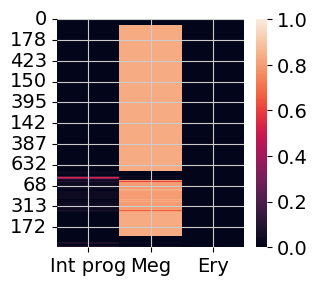

In [113]:
sns.heatmap((last_step.loc[:,['Int prog','Meg','Ery']]))

In [114]:
DT_v0 = DT_analysis(adata, f"results/ery_mk_Aug1_multiscaled/pde_params_tsense_1")

In [115]:
ct_evo = DT_v0.annotate_trajectory(config.dataset_config['cellstate_key'], 'anno_man')

In [116]:
last_step = []
for t in DT_v0.trajectory_dict:
    last_step.append(ct_evo[t].query('`step`==10'))
last_step = pd.concat(last_step, axis=0)

<Axes: >

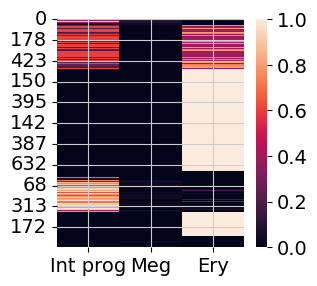

In [117]:
sns.heatmap((last_step.loc[:,['Int prog','Meg','Ery']]))

In [56]:
summarize_cell_proportions(test_anno, adata.obs['anno_man'].cat.categories)

,Ery,HSC,Int prog,Meg
0,0,1.000000,0.000000,0.000000
1,0,0.866667,0.133333,0.000000
2,0,1.000000,0.000000,0.000000
3,0,0.466667,0.500000,0.033333
4,0,1.000000,0.000000,0.000000
...,...,...,...,...
100,0,1.000000,0.000000,0.000000
101,0,0.900000,0.100000,0.000000
102,0,0.933333,0.066667,0.000000
103,0,1.000000,0.000000,0.000000
